In [50]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

To help in computing neutrino oscillation probabilities in real experimental setups, the `earth` module of Mag$\nu$s contains routines to compute the zenith angle of the location of one point on the surface of the Earth as measured from a different point, i.e., the position of a neutrino source measured from the position of a neutrino detector.  (These routines assume that the Earth is spherical, that the distribution of matter inside it radially symmetric, as in the Preliminary Reference Earth Model, and that the locations are on the surface, not underground.  Users can write their own functions to deal with these cases.)

The `earth` module contains predefined coordinates for a few significant locations:

In [51]:
earth.loc_coords_dms

{'baikal': {'lat': (51, 45, 54), 'lon': (104, 24, 54)},
 'cern': {'lat': (46, 14, 1.8), 'lon': (6, 3, 11.4)},
 'desy': {'lat': (53, 34, 19.79), 'lon': (9, 52, 27.59)},
 'ess': {'lat': (55, 44, 6), 'lon': (13, 15, 5.04)},
 'fermilab': {'lat': (41, 49, 55), 'lon': (-88, 15, 26)},
 'gran_sasso': {'lat': (42, 25, 15.8), 'lon': (13, 30, 58.43)},
 'homestake': {'lat': (44, 21, 5.76), 'lon': (-103, 45, 4.68)},
 'kamioka': {'lat': (36, 25, 50.05), 'lon': (137, 18, 41.15)},
 'km3net_arca': {'lat': (36, 16, 0), 'lon': (16, 6, 0)},
 'km3net_orca': {'lat': (42, 48, 0), 'lon': (6, 2, 0)},
 'north_pole': {'lat': (90, 0, 0), 'lon': (0, 0, 0)},
 'pyhaasalmi': {'lat': (63, 39, 31), 'lon': (26, 2, 28)},
 'snolab': {'lat': (46, 28, 18), 'lon': (-81, 11, 12)},
 'south_pole': {'lat': (-90, 0, 0), 'lon': (0, 0, 0)},
 'tokai': {'lat': (36, 27, 59), 'lon': (140, 36, 24)}}

The coordinates are tuples of (days, minutes, seconds).  This is the format in which the coordinates are pased to the functions below.  When defining custom locations, the user must feed them in this format to the functions.

Given the latitude (`lat`) and longitude (`lon`) of positions 1 (source) and 2 (detector) on the surface of the Earth, the chord length between them (i.e., the straight-line distance between them through the Earth) is computed with the `chord_length_inside_earth` function and the zenith angle of position 2 measured from position 1 is computed with the `costhz_between_points_on_surface` function.

In [52]:
# DUNE setup: from Fermilab (source) to Homestake (far detector)
lat1, lon1 = earth.loc_coords_dms['fermilab']['lat'], earth.loc_coords_dms['fermilab']['lon']
lat2, lon2 = earth.loc_coords_dms['homestake']['lat'], earth.loc_coords_dms['homestake']['lon']

baseline = earth.chord_length_inside_earth(lat1, lon1, lat2, lon2)
print("Baseline from Fermilab to Homestake: " + str(baseline) + " km")

costhz = earth.costhz_between_points_on_surface(lat1, lon1, lat2, lon2)
print("Cosine of zenith angle of Fermilab measured from Homestake: " + str(costhz))

Baseline from Fermilab to Homestake: 1207.1802288066992 km
Cosine of zenith angle of Fermilab measured from Homestake: -0.09474024712028718


Now that we know the zenith angle of the source as measured from the detector, we can compute and plot neutrino oscillation probabilities as usual (for details, see the example Mag$\nu$s notebooks `2_magnus_2nu_vacuum_matter.ipynb` and `3_magnus_3nu_vacuum_matter.ipynb` ).

To illustrate this, below, we consider an artificial setup of a neutrino beam with adjustable direction shot from Fermilab to several detector locations.

In [77]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Electron number density inside Earth, using the PREM density model
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5) # [eV^{-3}]

# Coherent forward potential inside Earth, using the PREM density model
def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

# Vacuum Hamiltonian without the 1/E prefactor 
H_vac_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False)

# Hamiltonian including matter effects inside Earth using the PREM density model
def H_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return (1/energy)*H_vac_energy_indep - hamiltonians3nu.hamiltonian_3nu_matter(VCC_func_prem(r/gd.CONV_KM_TO_INV_EV))

# Cosines of zenith angles of Fermilab measured from the detector locations (we would get the same result if we seapped them, since we
# consider that Earth is radially symmetric)
detectors = ['SNOLAB', 'Homestake', 'CERN', "South Pole"]
costhz_arr = [earth.costhz_between_points_on_surface(earth.loc_coords_dms[det.lower().replace(" ", "_")]['lat'], 
                                                     earth.loc_coords_dms[det.lower().replace(" ", "_")]['lon'],
                                                     earth.loc_coords_dms['fermilab']['lat'], 
                                                     earth.loc_coords_dms['fermilab']['lon']) 
             for det in detectors]

# Maximum baselines inside the Earth
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] # [km]

# Helper function for labeling plots
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

First, we compute the probabilities vs. baseline:

In [78]:
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.*gd.UNIT_MEV # [eV]

l_min = 1.e2 # [km]

# Generate probabilities for the different directions
distances_arr, prob_arr = [], []
l_npts = 3000
for i in range(len(costhz_arr)):
    print("detector = " + detectors[i])
    distances = np.logspace(np.log10(l_min), np.log10(l_max_arr[i]), l_npts) # [km
    distances_arr.append(distances)
    prob = np.array([oscprob.osc_prob(lambda ll: H_func_prem(costhz_arr[i], ll, energy), 0, l*gd.CONV_KM_TO_INV_EV,
                                      n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for l in distances]) 
    prob_arr.append(prob)

detector = SNOLAB
detector = Homestake
detector = CERN
detector = South Pole


Now we plot them:

Text(0, 0.5, 'Three-neutrino probability,~$P_{\\nu_e \\to \\nu_e}$')

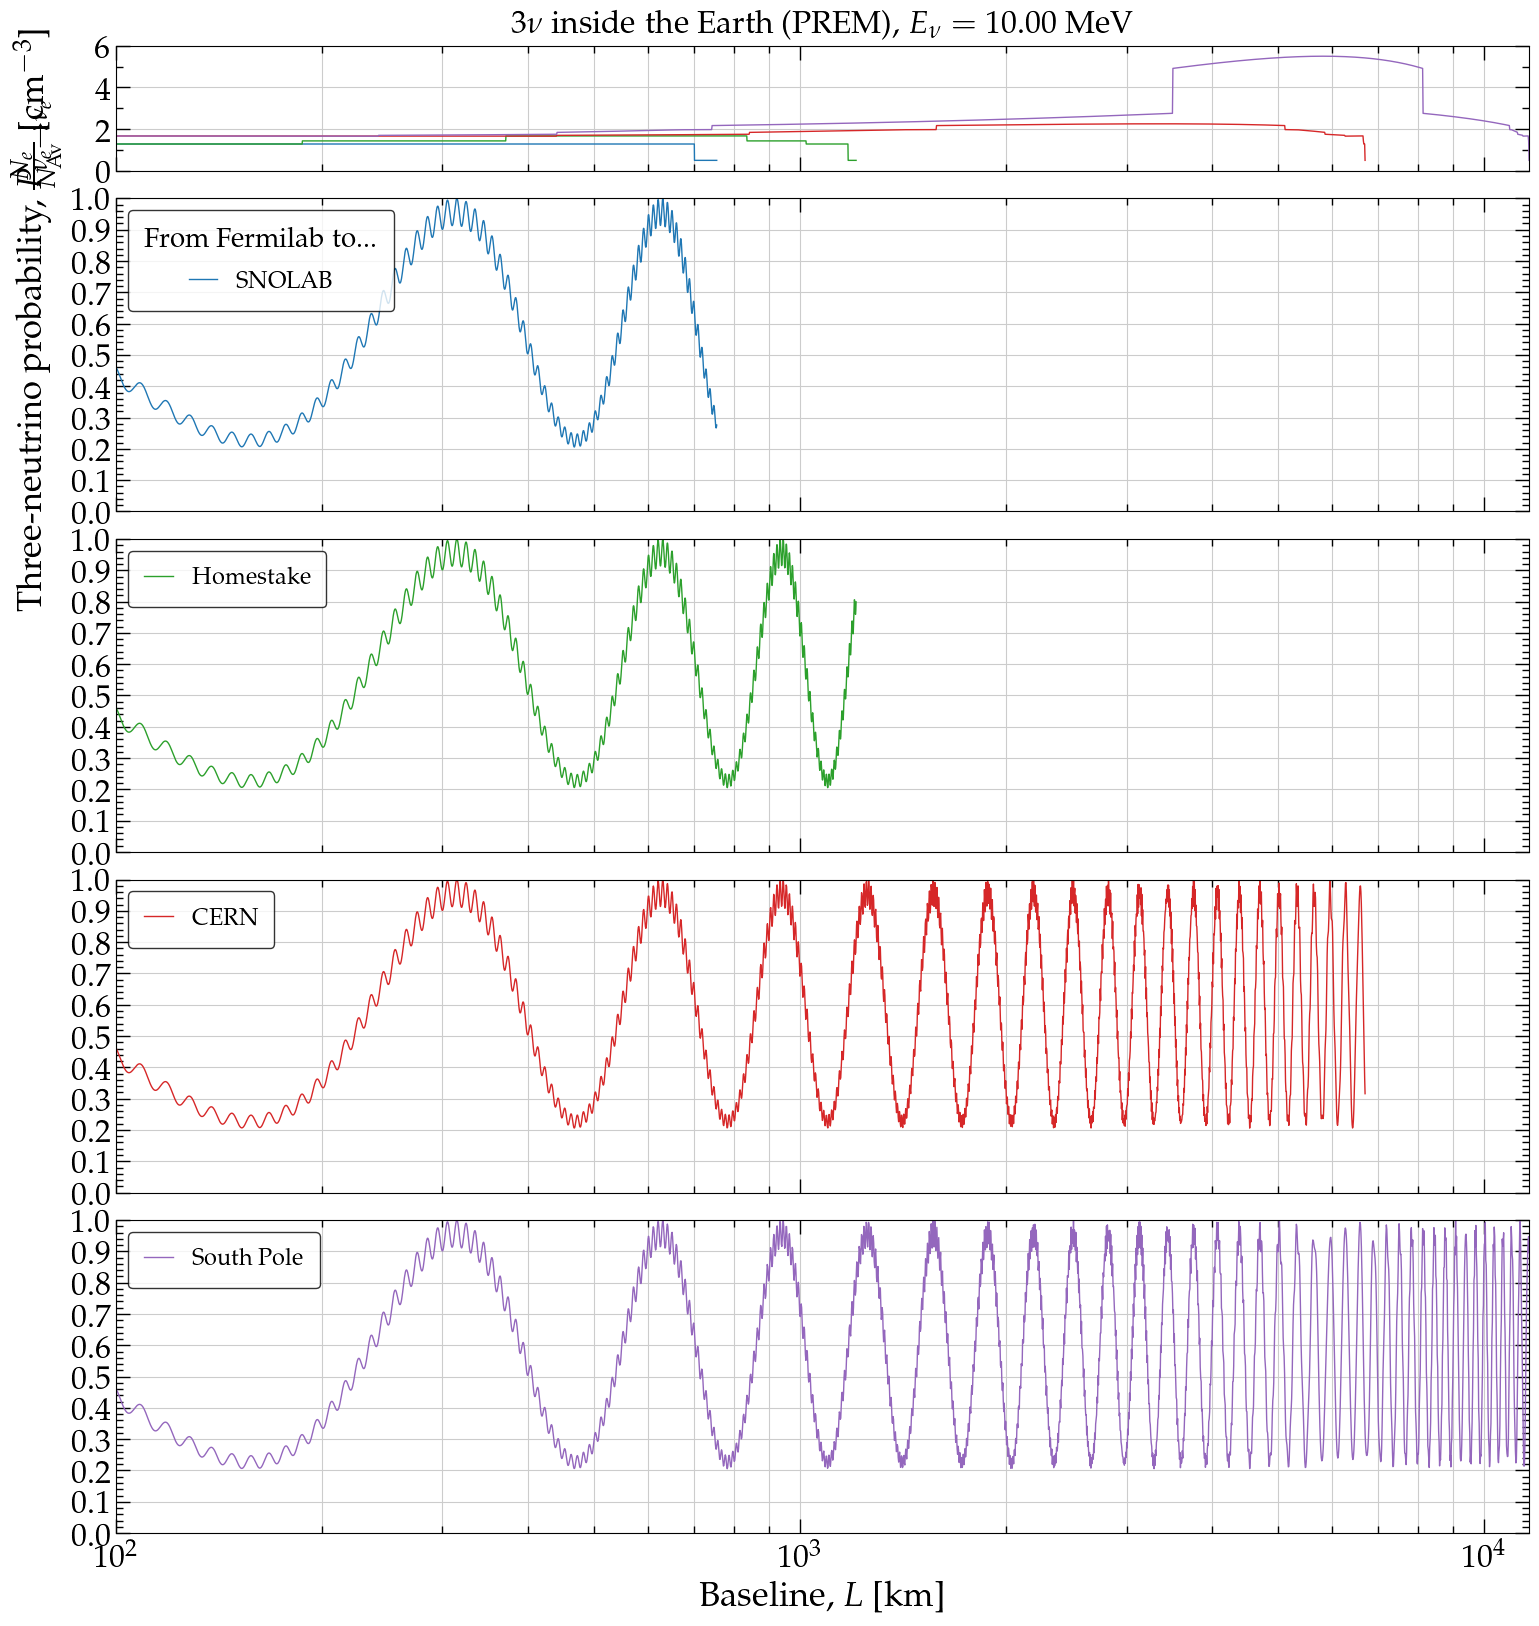

In [79]:
heights = [0.4, 1.0, 1.0, 1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=5, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,18])
fig.subplots_adjust(hspace=0.1, wspace=0.1)

lc = ['C0', 'C2', 'C3', 'C4']
ls = ['-', '-', '-', '-']

# Probabilities
for i in range(len(costhz_arr)):
    num_density_e = np.array([num_density_e_func_prem(earth.earth_radial_distance_from_depth(costhz_arr[i], l)) 
                              for l in distances_arr[i]])
    num_density_e = 1.0/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) * num_density_e
    ax[0].plot(distances_arr[i], num_density_e, lw=1, ls=ls[i], c=lc[i])
    ax[i+1].plot(distances_arr[i], prob_arr[i], lw=1, c=lc[i], ls=ls[i], label=detectors[i])

# Legend
for i in range(len(costhz_arr)):
    ax[i+1].legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2, handleheight=0.7,
                 borderpad=0.7, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=4, 
                 title=r'From Fermilab to...' if i == 0 else '')

# Formatting
for i, axx in enumerate(ax):
    axx.set_xscale('log')
    axx.set_xlim(l_min, max(l_max_arr))
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
    if (i != 0):
        axx.set_ylim(0, 1)
        axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
        axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    if (i != 4):
        axx.xaxis.set_ticklabels([])
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=25)
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=2))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].set_ylim(0, 6)
ax[0].set_title(r'$3\nu$~inside the Earth (PREM), $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=23, pad=10)
ax[4].set_xlabel(r'Baseline, $L$~[km]')
ax[1].set_ylabel(r'Three-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=15)


Finally, we compute the probabilities vs. energy for the full baseline in each case:

In [80]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 3000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Generate probabilities for the different directions
prob_arr = []
for i in range(len(costhz_arr)):
    print("detector = " + detectors[i])
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_arr[i], l, enu*gd.UNIT_MEV), 
                                      0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_arr.append(prob)

detector = SNOLAB
detector = Homestake
detector = CERN
detector = South Pole


And now we plot them:

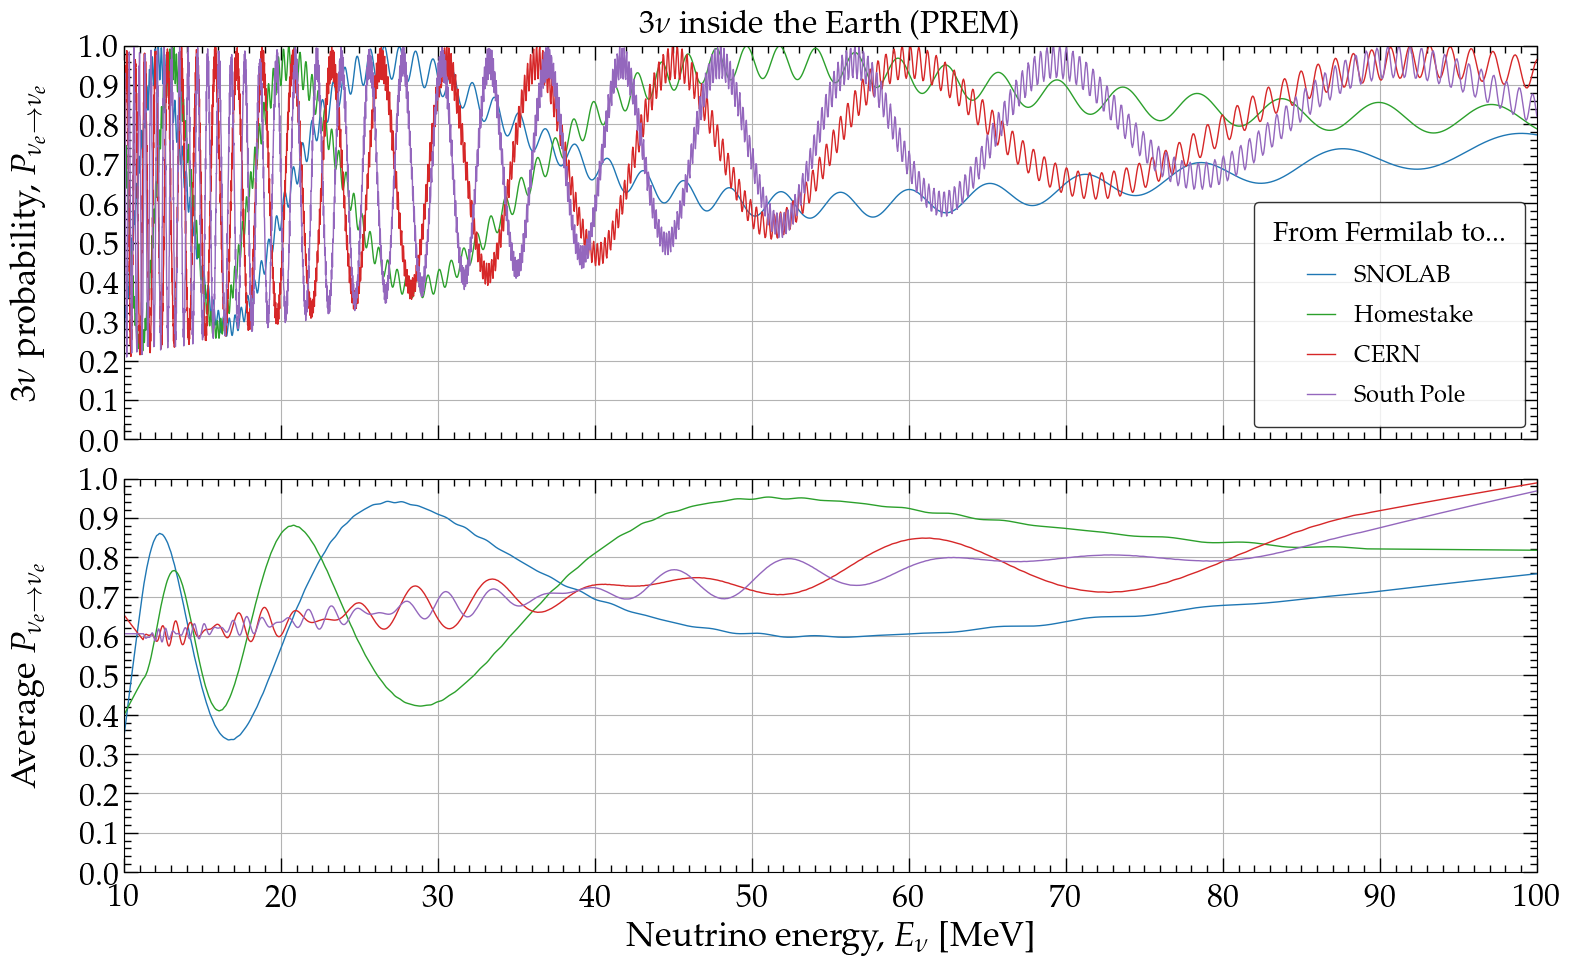

In [83]:
heights = [1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,10])
fig.subplots_adjust(hspace=0.1, wspace=0.1)

lc = ['C0', 'C2', 'C3', 'C4']
ls = ['-', '-', '-', '-']

# Probabilities
for i in range(len(costhz_arr)):
    ax[0].plot(energies, prob_arr[i], lw=1, c=lc[i], ls=ls[i], label=detectors[i])
    ax[1].plot(energies, sp.signal.savgol_filter(prob_arr[i], window_length=301, polyorder=1), lw=1, c=lc[i], ls=ls[i]) #201

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='lower right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'From Fermilab to...')

# Formatting
ax[0].set_title(r'$3\nu$~inside the Earth (PREM)', fontsize=23, pad=10)
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax[0].set_ylabel(r'$3\nu$~probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[1].set_ylabel(r'Average~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].xaxis.set_ticklabels([])
for axx in ax:
    axx.set_xlim(energy_min, energy_max)
    axx.set_ylim(0, 1)
    # axx.set_xscale('log')
    axx.grid(visible=True, c='0.7')
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))